# 06 — 1D-CNN Baseline
**Project:** Quantum Machine Learning for Physiological Stress Classification  
**Author:** Kenza Qribis

---

## Purpose
Implement and evaluate a 1D Convolutional Neural Network as the deep learning baseline.
Unlike classical ML models and quantum models which operate on hand-crafted features,
the CNN learns directly from raw windowed physiological signals.

## Why Full Dataset (No Subsampling)?
CNNs are gradient-based and require sufficient data for stable training and
meaningful filter learning. 150 samples per class is too small for a CNN to
converge reliably. The full WESAD dataset is used here.
This is documented in methodology as a deliberate design decision.

## Architecture
```
Input (window_samples x n_channels)
  -> Conv1D(32, kernel=7) + BatchNorm + ReLU + MaxPool
  -> Conv1D(64, kernel=5) + BatchNorm + ReLU + MaxPool
  -> Conv1D(128, kernel=3) + BatchNorm + ReLU + AdaptiveAvgPool
  -> Flatten
  -> Linear(128) + Dropout(0.5)
  -> Linear(n_classes)
```

## Datasets & Tasks
| Dataset | Task      | Input                          |
|---------|-----------|--------------------------------|
| WESAD   | Binary    | Raw chest signals, 60s windows |
| WESAD   | 3-class   | Raw chest signals, 60s windows |

## Evaluation
Leave-One-Subject-Out (LOSO) — same protocol as classical baselines.

---


## 0. Configuration

In [15]:
import os, json, time, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)

warnings.filterwarnings('ignore')

# ── SET THIS ──────────────────────────────────────────────────────────────────
WESAD_PATH = r"C:/Users/ACER/Desktop/APPLIED RESEARCH/Applied-Research/data/WESAD" 
# ─────────────────────────────────────────────────────────────────────────────

RESULTS_ROOT    = os.path.join('..', 'results')
PLOTS_DIR       = os.path.join(RESULTS_ROOT, 'plots', '06_cnn_baseline')
LOGS_DIR        = os.path.join(RESULTS_ROOT, 'logs')
OUTPUT_DATA_DIR = os.path.join(RESULTS_ROOT, 'output_data')
for d in [PLOTS_DIR, LOGS_DIR, OUTPUT_DATA_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Subjects & labels ─────────────────────────────────────────────────────────
ALL_SUBJECTS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
LABEL_MAP    = {1: 'baseline', 2: 'stress', 3: 'amusement'}
BINARY_MAP   = {1: 0, 2: 1}
THREE_MAP    = {1: 0, 2: 1, 3: 2}

# ── Signal config ─────────────────────────────────────────────────────────────
FS           = 700
WINDOW_S     = 30
STEP_S       = 10
PURITY       = 0.80
WIN_SAMP     = WINDOW_S * FS
STEP_SAMP    = STEP_S   * FS

# Downsample to 100Hz before CNN input
FS_TARGET    = 100
DOWNSAMPLE_F = FS // FS_TARGET   # = 7
WIN_SAMP_DS  = WINDOW_S * FS_TARGET  # = 6000 samples

# Chest signals used as CNN input channels
# ACC is 3-axis so we use magnitude — gives 5 channels total
SIGNAL_NAMES = ['ECG', 'EDA', 'EMG', 'Resp', 'Temp']

# ── CNN training config ───────────────────────────────────────────────────────
EPOCHS       = 50
BATCH_SIZE   = 32
LR           = 3e-3
RANDOM_STATE = 42

# Subsample raw windows per subject per class for CNN
# (still uses full data compared to quantum — but caps per-subject imbalance)
MAX_WINDOWS_PER_CLASS = None   # None = use all windows

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('Configuration ready.')
print(f'  Device     : {DEVICE}')
print(f'  Epochs     : {EPOCHS}')
print(f'  Batch size : {BATCH_SIZE}')
print(f'  Window     : {WINDOW_S}s  Step: {STEP_S}s')
print(f'  Plots dir  : {os.path.abspath(PLOTS_DIR)}')


Configuration ready.
  Device     : cpu
  Epochs     : 50
  Batch size : 32
  Window     : 30s  Step: 10s
  Plots dir  : c:\Users\ACER\Desktop\APPLIED RESEARCH\Applied-Research\results\plots\06_cnn_baseline


## 1. Raw Signal Extraction
Extract raw windowed signals from WESAD pickle files.
Each window becomes one sample: shape (n_channels, window_samples).

In [19]:
from scipy import signal as scipy_signal

def load_subject(wesad_path, sid):
    pkl = os.path.join(wesad_path, f'S{sid}', f'S{sid}.pkl')
    with open(pkl, 'rb') as f:
        return pickle.load(f, encoding='latin1')

def bandpass(sig, lo, hi, fs=700, order=4):
    nyq = fs / 2
    b, a = scipy_signal.butter(order, [lo/nyq, hi/nyq], btype='band')
    return scipy_signal.filtfilt(b, a, sig)

def lowpass(sig, cut, fs=700, order=4):
    nyq = fs / 2
    b, a = scipy_signal.butter(order, cut/nyq, btype='low')
    return scipy_signal.filtfilt(b, a, sig)

def get_window_label(lbl_win, purity=PURITY):
    valid = np.isin(lbl_win, [1, 2, 3])
    if valid.sum() / len(lbl_win) < purity:
        return -1
    from collections import Counter
    cnt = Counter(lbl_win[valid])
    maj_lbl, maj_cnt = cnt.most_common(1)[0]
    return maj_lbl if maj_cnt / len(lbl_win) >= purity else -1

def extract_raw_windows(wesad_path, sid, label_map):
    data   = load_subject(wesad_path, sid)
    labels = data['label']
    chest  = data['signal']['chest']

    # Preprocess signals
    ecg  = bandpass(np.array(chest['ECG']).flatten(), 0.5, 40.0)
    eda  = lowpass( np.array(chest['EDA']).flatten(), 1.0)
    emg  = bandpass(np.array(chest['EMG']).flatten(), 20.0, 340.0) \
           if 'EMG' in chest else np.zeros(len(ecg))
    resp = bandpass(np.array(chest['Resp']).flatten(), 0.1, 0.5)
    temp = np.array(chest['Temp']).flatten()

    # Downsample all signals from 700Hz to 100Hz
    signals = np.stack([ecg, eda, emg, resp, temp], axis=0)  # (5, n_samples)
    signals = signals[:, ::DOWNSAMPLE_F]                       # (5, n_samples//7)
    labels_ds = labels[::DOWNSAMPLE_F]                         # downsample labels too

    WIN_SAMP_USE  = WIN_SAMP_DS
    STEP_SAMP_USE = WINDOW_S * FS_TARGET // 2   # 50% overlap at 100Hz

    X_wins, y_wins = [], []
    n = len(labels_ds)

    for start in range(0, n - WIN_SAMP_USE + 1, STEP_SAMP_USE):
        end       = start + WIN_SAMP_USE
        lbl_win   = labels_ds[start:end]
        win_label = get_window_label(lbl_win)

        if win_label not in label_map:
            continue

        win = signals[:, start:end]   # (5, 6000)
        mu  = win.mean(axis=1, keepdims=True)
        std = win.std(axis=1,  keepdims=True) + 1e-8
        win = (win - mu) / std

        X_wins.append(win)
        y_wins.append(label_map[win_label])

    if len(X_wins) == 0:
        return np.empty((0, 5, WIN_SAMP_USE)), np.empty(0, dtype=int)

    return np.stack(X_wins).astype(np.float32), np.array(y_wins, dtype=np.int64)


print('Raw signal extraction functions defined.')
print(f'Output shape per subject: (n_windows, 5_channels, {WIN_SAMP}_samples)')

# Quick test on S2
print('\nTest extraction on S2...')
X_test, y_test = extract_raw_windows(WESAD_PATH, 2, BINARY_MAP)
print(f'  S2 binary: X={X_test.shape}  y={y_test.shape}  '
      f'labels={dict(Counter(y_test.tolist()))}')


Raw signal extraction functions defined.
Output shape per subject: (n_windows, 5_channels, 21000_samples)

Test extraction on S2...
  S2 binary: X=(114, 5, 3000)  y=(114,)  labels={0: 75, 1: 39}


## 2. CNN Architecture

In [20]:
class CNN1D(nn.Module):
    """
    1D Convolutional Neural Network for physiological signal classification.
    Input : (batch, n_channels, window_samples)
    Output: (batch, n_classes)
    """
    def __init__(self, n_channels=5, n_classes=2, dropout=0.5):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)   # global average pooling
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        return self.classifier(x)


# Quick architecture check
_model = CNN1D(n_channels=5, n_classes=2)
_x     = torch.randn(4, 5, WIN_SAMP_DS)
_out   = _model(_x)
print(f'Architecture check: input={list(_x.shape)} -> output={list(_out.shape)}')
total_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')
del _model, _x, _out


Architecture check: input=[4, 5, 3000] -> output=[4, 2]
Trainable parameters: 53,378


## 3. Training & Evaluation Utilities

In [21]:
from torch.utils.data import WeightedRandomSampler

def get_weighted_sampler(y):
    counts  = np.bincount(y)
    weights = 1.0 / counts[y]
    weights = torch.tensor(weights, dtype=torch.float32)
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

def get_class_weights(y, n_classes, device):
    """Compute inverse-frequency class weights for imbalanced data."""
    counts = np.bincount(y, minlength=n_classes).astype(float)
    counts = np.where(counts == 0, 1, counts)
    weights = 1.0 / counts
    weights = weights / weights.sum() * n_classes
    return torch.tensor(weights, dtype=torch.float32).to(device)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (out.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out  = model(X_batch)
            loss = criterion(out, y_batch)
            total_loss += loss.item() * len(y_batch)
            preds = out.argmax(1)
            correct += (preds == y_batch).sum().item()
            total   += len(y_batch)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_true.extend(y_batch.cpu().numpy().tolist())
    return total_loss/total, correct/total, all_preds, all_true


def compute_metrics(y_true, y_pred, average='macro'):
    return {
        'accuracy' : float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred,
                           average=average, zero_division=0)),
        'recall'   : float(recall_score(y_true, y_pred,
                           average=average, zero_division=0)),
        'f1'       : float(f1_score(y_true, y_pred,
                           average=average, zero_division=0)),
    }


print('Training utilities defined.')


Training utilities defined.


## 4. LOSO Pipeline
> This section loads raw windows for all subjects and runs LOSO.
> Expect 5-15 minutes depending on your hardware.

In [22]:
from tqdm.notebook import tqdm

def run_cnn_loso(wesad_path, subjects, label_map, task_name,
                 n_classes, epochs=EPOCHS, batch_size=BATCH_SIZE,
                 lr=LR, average='macro'):
    """
    LOSO cross-validation for the 1D-CNN.
    Loads raw windows per subject, trains from scratch each fold.
    """
    fold_rows   = []
    cm_accum    = np.zeros((n_classes, n_classes), dtype=int)
    train_curves= []   # list of (fold, epoch, train_loss, train_acc)

    print(f'\n=== {task_name} — CNN LOSO ({len(subjects)} folds) ===')
    print(f'    Epochs={epochs}  BS={batch_size}  LR={lr}  Device={DEVICE}')

    # Pre-load all subjects
    print('  Pre-loading all subjects...')
    subject_data = {}
    for sid in tqdm(subjects, desc='Loading'):
        X, y = extract_raw_windows(wesad_path, sid, label_map)
        subject_data[sid] = (X, y)
        print(f'    S{sid}: {X.shape[0]} windows  {dict(Counter(y.tolist()))}')

    for fold_i, test_sid in enumerate(subjects):
        # Build train/test splits
        X_train_list, y_train_list = [], []
        for sid in subjects:
            if sid == test_sid:
                continue
            X_s, y_s = subject_data[sid]
            if len(X_s) > 0:
                X_train_list.append(X_s)
                y_train_list.append(y_s)

        X_train = np.concatenate(X_train_list, axis=0)
        y_train = np.concatenate(y_train_list, axis=0)
        X_test, y_test = subject_data[test_sid]

        if len(X_test) == 0:
            print(f'  Fold {fold_i+1}: S{test_sid} has no valid windows — skipping')
            continue

        # Class weights for imbalance
        criterion = nn.CrossEntropyLoss()

        # DataLoaders
        train_ds = TensorDataset(
            torch.tensor(X_train, dtype=torch.float32),
            torch.tensor(y_train, dtype=torch.long))
        test_ds  = TensorDataset(
            torch.tensor(X_test,  dtype=torch.float32),
            torch.tensor(y_test,  dtype=torch.long))
        sampler      = get_weighted_sampler(y_train)
        train_loader = DataLoader(train_ds, batch_size=batch_size,
                                  sampler=sampler, drop_last=False)
        test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                                  shuffle=False, drop_last=False)

        # Fresh model each fold
        model     = CNN1D(n_channels=5, n_classes=n_classes).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

        t0 = time.time()
        for epoch in range(epochs):
            tr_loss, tr_acc = train_epoch(
                model, train_loader, optimizer, criterion, DEVICE)
            scheduler.step()
            train_curves.append({
                'fold': fold_i+1, 'epoch': epoch+1,
                'train_loss': tr_loss, 'train_acc': tr_acc
            })
        train_time = time.time() - t0

        # Evaluate
        t1 = time.time()
        _, _, y_pred, y_true = eval_epoch(
            model, test_loader, criterion, DEVICE)
        test_time = time.time() - t1

        metrics = compute_metrics(y_true, y_pred, average=average)
        classes = sorted(label_map.values())
        cm      = confusion_matrix(y_true, y_pred, labels=classes)
        cm_accum += cm

        fold_rows.append({
            'task'        : task_name,
            'model'       : '1D-CNN',
            'fold'        : fold_i + 1,
            'test_subject': int(test_sid),
            'train_size'  : len(y_train),
            'test_size'   : len(y_test),
            'train_time'  : round(train_time, 2),
            'test_time'   : round(test_time, 4),
            **metrics
        })

        print(f'  Fold {fold_i+1:2d}/{len(subjects)} '
              f'test=S{test_sid:2d}  '
              f'acc={metrics["accuracy"]:.3f}  '
              f'f1={metrics["f1"]:.3f}  '
              f'train={train_time:.0f}s')

        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return (pd.DataFrame(fold_rows),
            cm_accum,
            pd.DataFrame(train_curves))


print('CNN LOSO pipeline defined.')


CNN LOSO pipeline defined.


## 5. WESAD Binary Task
> Trains 15 CNN models (one per LOSO fold). Expect 10–20 minutes.

In [23]:
results_bin, cm_bin, curves_bin = run_cnn_loso(
    wesad_path = WESAD_PATH,
    subjects   = ALL_SUBJECTS,
    label_map  = BINARY_MAP,
    task_name  = 'WESAD_binary_CNN',
    n_classes  = 2,
    average    = 'macro'
)

print('\n=== WESAD Binary CNN — Mean Metrics ===')
print(results_bin[['accuracy','precision','recall','f1',
                    'train_time','test_time']].mean().round(4).to_string())
print(f'\nStd F1: {results_bin["f1"].std():.4f}')



=== WESAD_binary_CNN — CNN LOSO (15 folds) ===
    Epochs=50  BS=32  LR=0.003  Device=cpu
  Pre-loading all subjects...


Loading:   0%|          | 0/15 [00:00<?, ?it/s]

    S2: 114 windows  {0: 75, 1: 39}
    S3: 115 windows  {0: 74, 1: 41}
    S4: 117 windows  {0: 76, 1: 41}
    S5: 120 windows  {0: 78, 1: 42}
    S6: 119 windows  {0: 77, 1: 42}
    S7: 119 windows  {0: 78, 1: 41}
    S8: 119 windows  {0: 76, 1: 43}
    S9: 120 windows  {0: 78, 1: 42}
    S10: 125 windows  {0: 78, 1: 47}
    S11: 121 windows  {0: 77, 1: 44}
    S13: 121 windows  {0: 77, 1: 44}
    S14: 121 windows  {0: 77, 1: 44}
    S15: 122 windows  {0: 78, 1: 44}
    S16: 120 windows  {0: 77, 1: 43}
    S17: 125 windows  {0: 78, 1: 47}
  Fold  1/15 test=S 2  acc=0.658  f1=0.397  train=123s
  Fold  2/15 test=S 3  acc=0.643  f1=0.392  train=124s
  Fold  3/15 test=S 4  acc=0.650  f1=0.394  train=115s
  Fold  4/15 test=S 5  acc=0.650  f1=0.394  train=113s
  Fold  5/15 test=S 6  acc=0.647  f1=0.393  train=114s
  Fold  6/15 test=S 7  acc=0.655  f1=0.396  train=115s
  Fold  7/15 test=S 8  acc=0.639  f1=0.390  train=114s
  Fold  8/15 test=S 9  acc=0.650  f1=0.394  train=115s
  Fold  9/15 

## 6. WESAD 3-Class Task

In [24]:
results_3cl, cm_3cl, curves_3cl = run_cnn_loso(
    wesad_path = WESAD_PATH,
    subjects   = ALL_SUBJECTS,
    label_map  = THREE_MAP,
    task_name  = 'WESAD_3class_CNN',
    n_classes  = 3,
    average    = 'macro'
)

print('\n=== WESAD 3-Class CNN — Mean Metrics ===')
print(results_3cl[['accuracy','precision','recall','f1',
                     'train_time','test_time']].mean().round(4).to_string())
print(f'\nStd F1: {results_3cl["f1"].std():.4f}')



=== WESAD_3class_CNN — CNN LOSO (15 folds) ===
    Epochs=50  BS=32  LR=0.003  Device=cpu
  Pre-loading all subjects...


Loading:   0%|          | 0/15 [00:00<?, ?it/s]

    S2: 137 windows  {0: 75, 1: 39, 2: 23}
    S3: 138 windows  {0: 74, 1: 41, 2: 23}
    S4: 141 windows  {0: 76, 2: 24, 1: 41}
    S5: 144 windows  {0: 78, 2: 24, 1: 42}
    S6: 143 windows  {0: 77, 1: 42, 2: 24}
    S7: 143 windows  {0: 78, 2: 24, 1: 41}
    S8: 142 windows  {0: 76, 2: 23, 1: 43}
    S9: 143 windows  {0: 78, 1: 42, 2: 23}
    S10: 149 windows  {0: 78, 2: 24, 1: 47}
    S11: 144 windows  {0: 77, 1: 44, 2: 23}
    S13: 145 windows  {0: 77, 2: 24, 1: 44}
    S14: 145 windows  {0: 77, 1: 44, 2: 24}
    S15: 145 windows  {0: 78, 2: 23, 1: 44}
    S16: 143 windows  {0: 77, 1: 43, 2: 23}
    S17: 149 windows  {0: 78, 2: 24, 1: 47}
  Fold  1/15 test=S 2  acc=0.547  f1=0.236  train=141s
  Fold  2/15 test=S 3  acc=0.536  f1=0.233  train=148s
  Fold  3/15 test=S 4  acc=0.539  f1=0.233  train=149s
  Fold  4/15 test=S 5  acc=0.542  f1=0.234  train=151s
  Fold  5/15 test=S 6  acc=0.538  f1=0.233  train=147s
  Fold  6/15 test=S 7  acc=0.545  f1=0.235  train=148s
  Fold  7/15 test=

## 7. Results & Plots

In [25]:
all_cnn = pd.concat([results_bin, results_3cl], ignore_index=True)

summary_cnn = (
    all_cnn.groupby('task')
    .agg(
        accuracy_mean  = ('accuracy',   'mean'),
        accuracy_std   = ('accuracy',   'std'),
        precision_mean = ('precision',  'mean'),
        recall_mean    = ('recall',     'mean'),
        f1_mean        = ('f1',         'mean'),
        f1_std         = ('f1',         'std'),
        train_time_mean= ('train_time', 'mean'),
        test_time_mean = ('test_time',  'mean'),
    )
    .round(4)
    .reset_index()
)
summary_cnn['model'] = '1D-CNN'

print('=== 1D-CNN SUMMARY ===')
print(summary_cnn.to_string(index=False))

p = os.path.join(OUTPUT_DATA_DIR, 'cnn_baseline_summary.csv')
summary_cnn.to_csv(p, index=False)
print(f'\nSaved: {p}')

p2 = os.path.join(OUTPUT_DATA_DIR, 'cnn_baseline_per_fold.csv')
all_cnn.to_csv(p2, index=False)
print(f'Saved: {p2}')


=== 1D-CNN SUMMARY ===
            task  accuracy_mean  accuracy_std  precision_mean  recall_mean  f1_mean  f1_std  train_time_mean  test_time_mean  model
WESAD_3class_CNN         0.5366        0.0072          0.1789       0.3333   0.2328  0.0020         265.9860          0.1266 1D-CNN
WESAD_binary_CNN         0.6420        0.0100          0.3210       0.5000   0.3910  0.0037         116.4973          0.0527 1D-CNN

Saved: ..\results\output_data\cnn_baseline_summary.csv
Saved: ..\results\output_data\cnn_baseline_per_fold.csv


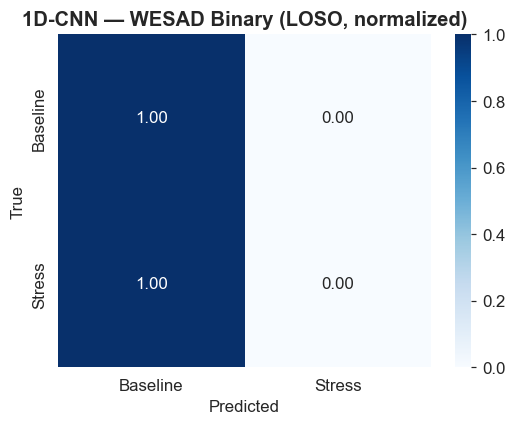

Saved: ..\results\plots\06_cnn_baseline\cm_cnn_wesad_binary.png


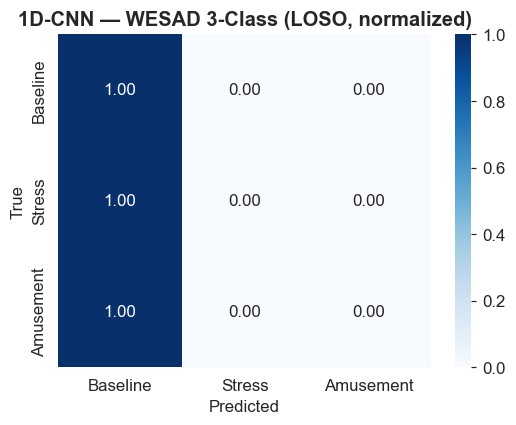

Saved: ..\results\plots\06_cnn_baseline\cm_cnn_wesad_3class.png


In [26]:
# Confusion matrices
def plot_cm(cm, class_names, title, save_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-10)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, vmin=0, vmax=1, annot_kws={'size':11})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

plot_cm(cm_bin, ['Baseline','Stress'],
        '1D-CNN — WESAD Binary (LOSO, normalized)',
        os.path.join(PLOTS_DIR, 'cm_cnn_wesad_binary.png'))

plot_cm(cm_3cl, ['Baseline','Stress','Amusement'],
        '1D-CNN — WESAD 3-Class (LOSO, normalized)',
        os.path.join(PLOTS_DIR, 'cm_cnn_wesad_3class.png'))


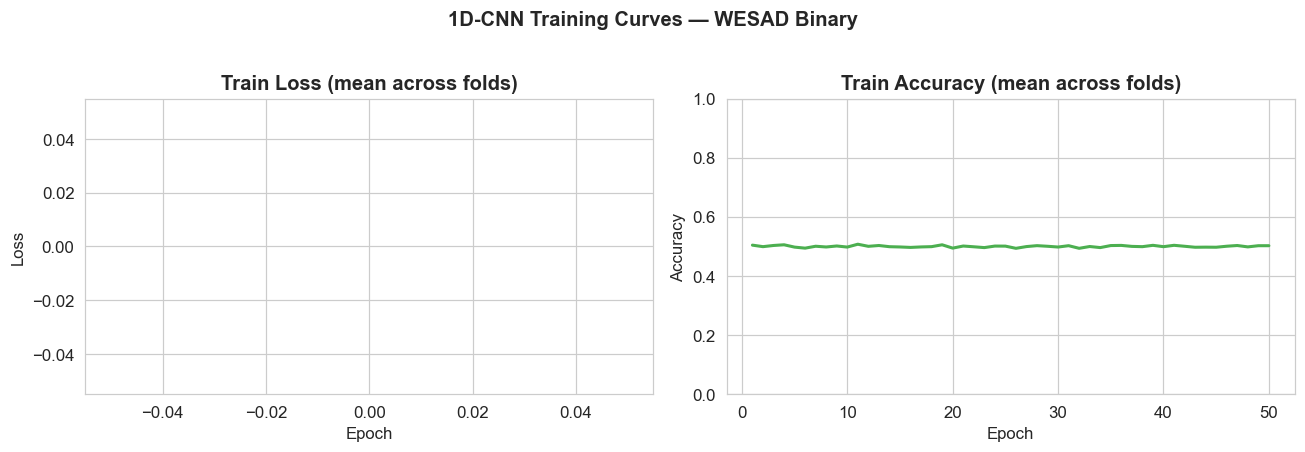

Saved: ..\results\plots\06_cnn_baseline\curves_cnn_wesad_binary.png


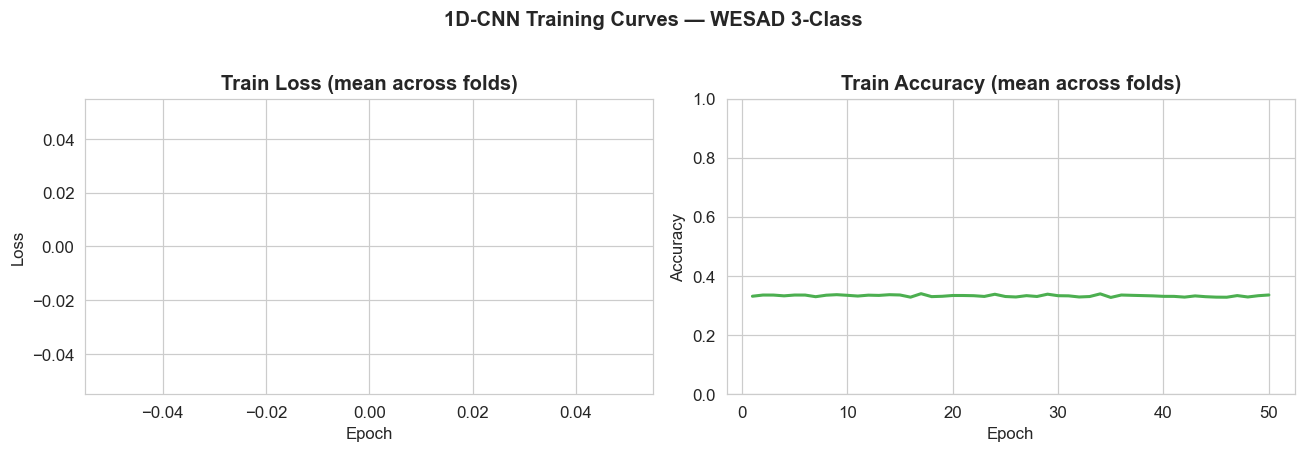

Saved: ..\results\plots\06_cnn_baseline\curves_cnn_wesad_3class.png


In [27]:
# Training curves — average across folds
for curves, task_label, fname in [
        (curves_bin, 'WESAD Binary', 'curves_cnn_wesad_binary.png'),
        (curves_3cl, 'WESAD 3-Class','curves_cnn_wesad_3class.png')]:

    mean_curves = curves.groupby('epoch')[['train_loss','train_acc']].mean()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(mean_curves.index, mean_curves['train_loss'],
                 color='#F44336', lw=2)
    axes[0].set_title('Train Loss (mean across folds)', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')

    axes[1].plot(mean_curves.index, mean_curves['train_acc'],
                 color='#4CAF50', lw=2)
    axes[1].set_title('Train Accuracy (mean across folds)', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1)

    plt.suptitle(f'1D-CNN Training Curves — {task_label}',
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    p = os.path.join(PLOTS_DIR, fname)
    plt.savefig(p, bbox_inches='tight'); plt.show()
    print(f'Saved: {p}')


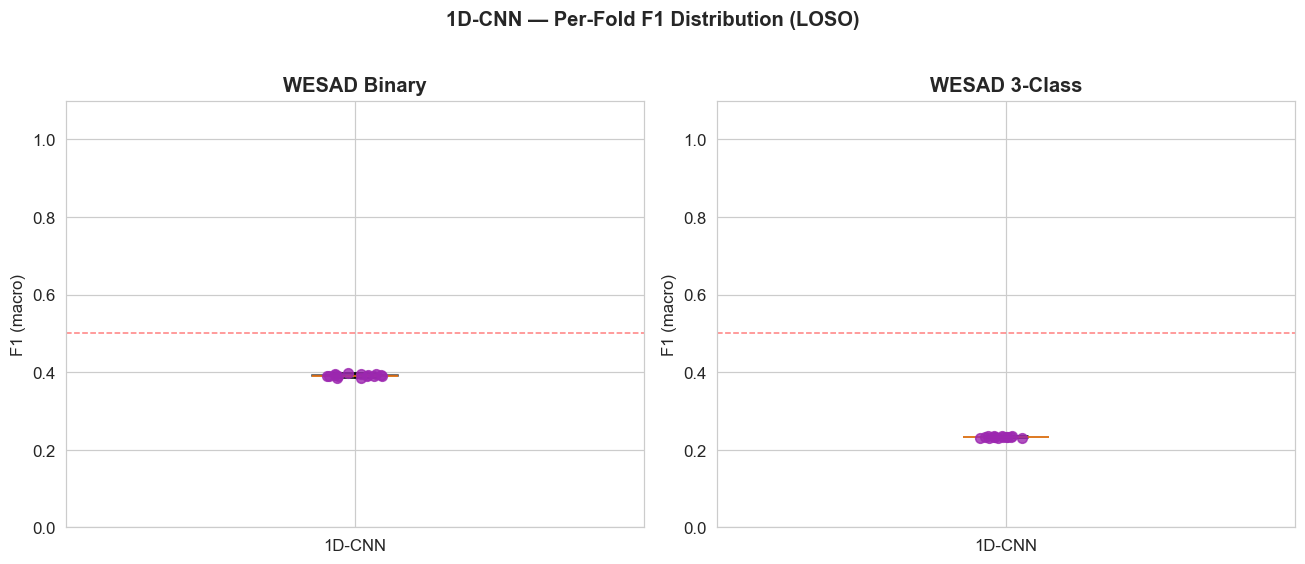

Saved: ..\results\plots\06_cnn_baseline\cnn_f1_per_fold_boxplot.png


In [28]:
# Per-fold F1 boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (task_key, task_label) in zip(axes, [
        ('WESAD_binary_CNN','WESAD Binary'),
        ('WESAD_3class_CNN','WESAD 3-Class')]):
    td = all_cnn[all_cnn['task']==task_key]['f1'].values
    ax.boxplot([td], patch_artist=True, labels=['1D-CNN'],
               boxprops=dict(facecolor='#9C27B0', alpha=0.7))
    ax.set_title(task_label, fontweight='bold')
    ax.set_ylabel('F1 (macro)')
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='red', linestyle='--', lw=1, alpha=0.5)
    # Overlay individual fold points
    ax.scatter(np.ones(len(td)) + np.random.uniform(-0.05,0.05,len(td)),
               td, color='#9C27B0', alpha=0.8, zorder=3, s=40)
plt.suptitle('1D-CNN — Per-Fold F1 Distribution (LOSO)',
             fontweight='bold', y=1.02)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, 'cnn_f1_per_fold_boxplot.png')
plt.savefig(p, bbox_inches='tight'); plt.show()
print(f'Saved: {p}')


In [29]:
# 3-class overlap: stress vs amusement
print('=== 1D-CNN: Stress/Amusement Confusion (WESAD 3-class) ===')
cm = cm_3cl
total_stress = cm[1, :].sum()
total_amuse  = cm[2, :].sum()
s_a = cm[1, 2] / total_stress if total_stress > 0 else 0
a_s = cm[2, 1] / total_amuse  if total_amuse  > 0 else 0
print(f'  Stress -> Amusement : {cm[1,2]}/{total_stress} ({s_a*100:.1f}%)')
print(f'  Amusement -> Stress : {cm[2,1]}/{total_amuse}  ({a_s*100:.1f}%)')

overlap_cnn = pd.DataFrame([{
    'model'                  : '1D-CNN',
    'stress->amusement_rate' : round(s_a, 4),
    'amusement->stress_rate' : round(a_s, 4),
}])
p = os.path.join(OUTPUT_DATA_DIR, 'cnn_stress_amusement_overlap.csv')
overlap_cnn.to_csv(p, index=False)
print(f'Saved: {p}')


=== 1D-CNN: Stress/Amusement Confusion (WESAD 3-class) ===
  Stress -> Amusement : 0/644 (0.0%)
  Amusement -> Stress : 0/353  (0.0%)
Saved: ..\results\output_data\cnn_stress_amusement_overlap.csv


## 8. Summary Log

In [30]:
summary_dict = {
    'notebook'      : '06_cnn_baseline',
    'timestamp'     : datetime.now().isoformat(),
    'architecture'  : {
        'type'      : '1D-CNN',
        'n_channels': 5,
        'blocks'    : ['Conv1d(32,k7)+BN+ReLU+MaxPool4',
                       'Conv1d(64,k5)+BN+ReLU+MaxPool4',
                       'Conv1d(128,k3)+BN+ReLU+AdaptiveAvgPool',
                       'Linear(128)+Dropout(0.5)+Linear(n_classes)'],
    },
    'training'      : {
        'epochs'    : EPOCHS,
        'batch_size': BATCH_SIZE,
        'lr'        : LR,
        'optimizer' : 'Adam + weight_decay=1e-4',
        'scheduler' : 'StepLR(step=10, gamma=0.5)',
        'data'      : 'Full dataset (no subsampling)',
        'justification': 'CNN requires sufficient data for stable gradient training'
    },
    'evaluation'    : 'LOSO',
    'results'       : {}
}

for _, row in summary_cnn.iterrows():
    summary_dict['results'][row['task']] = {
        'accuracy_mean': row['accuracy_mean'],
        'f1_mean'      : row['f1_mean'],
        'f1_std'       : row['f1_std'],
        'train_time_s' : row['train_time_mean'],
    }

summary_dict['next'] = '07_qsvm_experiments.ipynb'

p = os.path.join(LOGS_DIR, '06_cnn_baseline_summary.json')
with open(p,'w') as f: json.dump(summary_dict, f, indent=2)

print('=' * 60)
print('CNN BASELINE COMPLETE')
print('=' * 60)
print(json.dumps(summary_dict, indent=2))
print(f'\nLog saved: {p}')


CNN BASELINE COMPLETE
{
  "notebook": "06_cnn_baseline",
  "timestamp": "2026-05-09T22:20:05.712307",
  "architecture": {
    "type": "1D-CNN",
    "n_channels": 5,
    "blocks": [
      "Conv1d(32,k7)+BN+ReLU+MaxPool4",
      "Conv1d(64,k5)+BN+ReLU+MaxPool4",
      "Conv1d(128,k3)+BN+ReLU+AdaptiveAvgPool",
      "Linear(128)+Dropout(0.5)+Linear(n_classes)"
    ]
  },
  "training": {
    "epochs": 50,
    "batch_size": 32,
    "lr": 0.003,
    "optimizer": "Adam + weight_decay=1e-4",
    "scheduler": "StepLR(step=10, gamma=0.5)",
    "data": "Full dataset (no subsampling)",
    "justification": "CNN requires sufficient data for stable gradient training"
  },
  "evaluation": "LOSO",
  "results": {
    "WESAD_3class_CNN": {
      "accuracy_mean": 0.5366,
      "f1_mean": 0.2328,
      "f1_std": 0.002,
      "train_time_s": 265.986
    },
    "WESAD_binary_CNN": {
      "accuracy_mean": 0.642,
      "f1_mean": 0.391,
      "f1_std": 0.0037,
      "train_time_s": 116.4973
    }
  },
  "nex